In [1]:
# Install Required Libraries
%pip install tensorflow pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

2026-05-06 20:24:37.756492: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:24:37.786292: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load Dataset

data = pd.read_csv("stock_price.csv")

# Display First 5 Rows
print(data.head())

     Month   Sales
0  2015-01  209.93
1  2015-02  215.33
2  2015-03  247.60
3  2015-04  278.71
4  2015-05  253.11


In [3]:
# Select Sales Column as Stock Price

stock_data = data.iloc[:,1].values.reshape(-1,1)

# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(stock_data)

print(scaled_data[:5])

[[0.14536818]
 [0.15908456]
 [0.2410526 ]
 [0.32007417]
 [0.25504839]]


In [4]:
# Create Dataset Function

def create_dataset(dataset, time_step=5):

    X, Y = [], []

    for i in range(len(dataset)-time_step-1):

        a = dataset[i:(i+time_step), 0]

        X.append(a)

        Y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(Y)

# Create Sequences
time_step = 5

X, y = create_dataset(scaled_data, time_step)

print(X.shape)
print(y.shape)

(114, 5)
(114,)


In [5]:
# Reshape Data for RNN

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(114, 5, 1)


In [6]:
# Create RNN Model

model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(time_step,1)
))

model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Model Summary
model.summary()

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train Model

history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0119   
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0069 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057  
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066  
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059 
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 


In [8]:
# Predictions

predictions = model.predict(X)

# Convert Back to Original Scale

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y.reshape(-1,1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


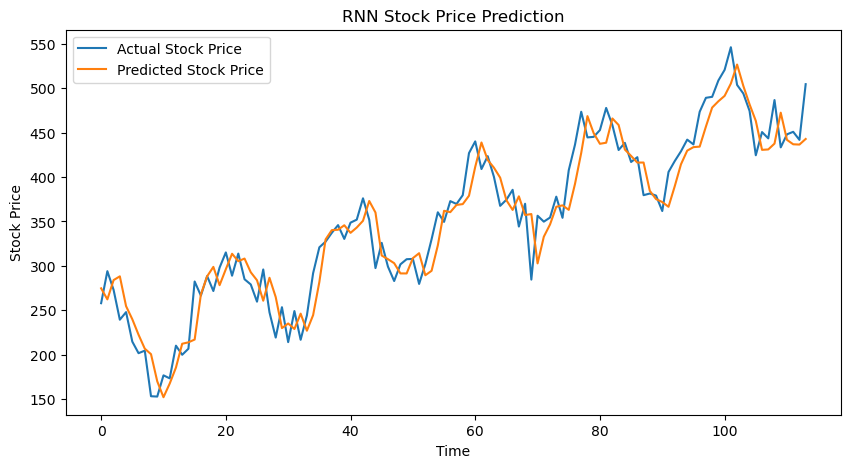

In [9]:
# Plot Results

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Stock Price")

plt.plot(predictions, label="Predicted Stock Price")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.title("RNN Stock Price Prediction")

plt.legend()

plt.show()